# Phase 2 EDA: Yelp Signals and Future Rent Growth

**Team:** Zane Mroue (zsm7), Grace Myers (gm586), Samy Lokanandi (sl3539), Ali Hasan (ah2434)

GITHUB: https://github.com/sl3539-svg/Data-Science-Project

## Research questions
1. Do ZIP-years with more gentrification-coded Yelp review language tend to experience higher rent growth in the following year?
2. Do business composition measures such as `gentrify_density` and `avg_price_range` line up with future rent growth?

- A ZIP-year is a single data point for one specific ZIP code in one specific year (for example ZIP 10027 in 2020)
- gentrify_density is the fraction of food businesses in a ZIP that belong to your gentrification-associated Yelp business categories
- for each ZIP, average “$–$$$$” price range across the Yelp food businesses included.

## Plan
- check data coverage and missingness,
- summarize the main variables,
- show a small number of focused plots,
- run a simple pooled regression with metro and year controls,
- test whether the result changes when we keep only higher-review ZIP-years.

## Data Description
Both datasets used are publicly available. No API keys or scraping needed.

---

### Dataset 1: Yelp Open Dataset

**Why we're using it:** Yelp provides a publicly available source of both business composition and user-generated text at the ZIP code level. This lets us measure two distinct cultural signals of gentrification: the *types* of businesses opening in a neighborhood, and the *language* people use to describe them.

**Observations and attributes:**
- `business.json` → one row per business listing. Key fields: `business_id`, `postal_code`, `categories` (pipe-delimited Yelp taxonomy), `attributes.RestaurantsPriceRange2`,`stars`, `review_count`
- `review.json` → one row per review. Key fields: `business_id`,, `review_id`, `user_id` `date`, `text`, `stars`
- We also use `user.json`, `checkin.json`, `tip.json`, and `photo.json` for supplementary context, but they are not part of our core analysis.

**Columns we focus on and why:**
- `categories`: used to flag businesses as gentrification-associated (e.g., "American (New)", "Wine Bars", "Gastropubs") - directly addresses RQ1
- `attributes.RestaurantsPriceRange2`: proxy for establishment upscaling over time - relevant to both RQs
- `review.text` + `review.date`: source of our 30-keyword NLP scan aggregated to ZIP × year - directly addresses RQ2
- `postal_code`: geographic unit for joining to Zillow rent data

**Why was it created?**  In the dataset’s terms and services, it states “The Data is made available by Yelp Inc. (“Yelp”) to enable you to access valuable local information to develop an academic project as part of an ongoing course of study”. This dataset was made publicly available for acedemic and research purposes.


**Who funded it?** Yelp Inc. This is an internal public-relations/research initiative; no external funding.

**Processes that influenced what data was observed:**
- *User self-selection:* Yelp reviewers skew younger, urban, and tech-savvy. Additionally, reviews and ratings rely on user's self reporting.

- *Business registration:* Only Yelp-listed businesses appear. Informal, cash-only, or older family restaurants (common in lower-income areas) are likely underrepresented.
- *Platform moderation:* Yelp filters some reviews from its public display; the academic dataset may reflect different coverage than what users see.
- *Geographic snapshot:* Metadata reflects business state as of ~2022; businesses that opened and closed within the study window may be missing.
- *Platform design:* Yelp decided what to measure and what types of interactions to record on its platform.

**Preprocessing done by Yelp:**
The data is Structured into JSON format, there is standardization of fields like dates (YYYY-MM-DD), ratings, and IDs, and IDs (user_id, business_id) allow joining datasets.

**Our Preprocessing Steps:**
Filtered to food/dining businesses, extracted price range from nested JSON attributes, built binary gentrification category flags, aggregated reviews to ZIP × year. Dropped placeholder ZIPs ('00000') and Canadian postal codes. Filtered to 5 focal metros. Dropped ZIP-years with fewer than 10 reviews.

**Were people aware of data use?** Yes, people are aware that their Yelp posts are public content. In [Yelp's ToS](https://terms.yelp.com/privacy/en_us/20260101_en_us/#Data-You-Share-With-Us) states "Your contributions to the Service are accessible to the public, including your photos, videos, ratings, reviews, posts, lists, bookmarks and collections, compliments, review reactions, and edits you suggest or provide to business pages". The dataset is anonymized (no PII). 

**Where to find raw source data:**  [https://business.yelp.com/data/resources/open-dataset/](https://business.yelp.com/data/resources/open-dataset/)


---

### Dataset 2: Zillow Observed Rent Index (ZORI)
**Link:** [https://www.zillow.com/research/data/](https://www.zillow.com/research/data/) - "ZORI (Smoothed): All Homes Plus Multifamily"

**Why we're using it:** Zillow's ZORI is a publicly available ZIP-code-level rent index, built from repeat-rent transactions (not just listed prices), making it a reliable measure of actual market rents, our primary dependent variable.

**Observations and attributes:**
- Raw format: one row per ZIP code (~7,782 ZIPs), one column per month (2015–present)
- After reshaping to long format: one row per (ZIP, month) observation with `rent_index` as the value

**Columns we focus on and why:**
- `avg_rent` (annual mean of monthly index): baseline rent level - used as a control in regression
- `rent_yoy_change` (% change year-over-year): captures rent dynamics within the study window
- `next_year_rent_yoy_change` (1-year lag): our primary **dependent variable** for RQ2 - lets us test whether Yelp signals in year T predict rent changes in T+1, addressing causality direction
- `RegionName` / `postal_code`: geographic key for merging with Yelp data

**Why was it created?** Zillow Research publishes ZORI monthly for public transparency about rental market conditions.

**Who funded it?** Zillow Group, Inc. (commercial). Zillow Research states it is *"independent of Zillow's business goals and is not a revenue center."* [About Zillow Research](https://www.zillow.com/research/about-us/)

**Processes that influenced what data is observed:**
- *Platform-based data collection:* biased toward listings included on Zillow
- *Geographic coverage limits:* has to have sufficient data to be included
- *Feature simplification:* housing characteristics are grouped
- *Repeated listing requirement:* ZORI requires listings that appear over time, not just once

**Preprocessing done by Zillow:**
- Zillow’s ZORI involves significant preprocessing and modeling including:
    - Use of regressions to estimate price changes
    - Smoothing to apply a 3-month moving average to reduce noise 
    - Convert index values into dollar rents using the middle 30% of listings
    - Uses a proprietary method to account for seasonality
    - Comprehensive details on Zillow’s Zori Methodology can be found [here](https://www.zillow.com/research/methodology-zori-repeat-rent-27092/)


**Our Preprocessing:**
Melted from wide to long format, extracted year from date column, computed annual averages and YoY % changes, created 1-year lag variable for predictive modeling. ZIP codes zero-padded to 5 digits for joining.

**Were people aware?** Landlords posting on Zillow agree to its ToS. Renters interact with listings but may not anticipate use in such data sources.

**Where to find raw source data:** Available for download at [https://www.zillow.com/research/data/](https://www.zillow.com/research/data/).

## Data Collection and Cleaning

Our full data collection and cleaning pipeline from Phase 1: https://github.com/sl3539-svg/Data-Science-Project/blob/phase2/notebooks/phase1.ipynb

Our data pipeline follows a multi-stage ETL process to combine cultural signals from Yelp with economic trends from Zillow:

- **Business Filtering & Feature Engineering:** We filtered the Yelp Business dataset (~150k entries) down to ~70k food and dining establishments. We extracted price range attributes and flagged businesses falling into 14 gentrification-associated categories (e.g., Coffee & Tea, Wine Bars, Vegan, Gastropubs).
- **Data Cleaning & Scoping:** We dropped invalid Yelp entries (placeholder ZIPs like '00000' and Canadian postal codes), and resolved city-name inconsistencies (e.g., "St. Petersburg" → "Saint Petersburg"). We then narrowed scope to five focal metros with high Yelp density and documented gentrification history: **Philadelphia (PA/NJ/DE), Nashville (TN), New Orleans (LA), Tampa (FL), and Indianapolis (IN).** We removed ZIP-years with fewer than 10 reviews to avoid overfitting to sparse observations.
- **Review NLP Pipeline:** We processed ~7 million Yelp reviews in 200k-row chunks, scanning for 30 gentrification-associated keywords (e.g., "aesthetic," "vibe," "artisan," "curated"). These were aggregated to the ZIP × year level to produce keyword frequencies and a composite `gentrify_language_score`.
- **Rent Index Processing:** We reshaped the Zillow ZORI dataset from wide to long format, calculated yearly average rents, and computed year-over-year (YoY) percentage changes.
- **Merging & Lagging:** We performed an inner join on (ZIP, year). We also created lagged rent variables (T+1) to test whether Yelp signals in year T predict rent changes in year T+1.

**Change from Phase 1 (addressing TA feedback):** The TA noted that filtering to ZIP overlap *before* processing reviews would be more efficient, since ~43% of Yelp ZIPs lack Zillow coverage and are ultimately discarded. For Phase 2, we acknowledge this optimization; the current pipeline processes all metro-filtered businesses through the NLP step first and filters to overlap ZIPs at merge time. A future rewrite could filter to overlap ZIPs earlier to reduce review processing volume by roughly half.

## Exploratory Analysis

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = "../data/processed/analysis_ready.csv"

df = pd.read_csv(DATA_PATH)

#Log-transform review volume so a few very large ZIP-years do not dominate the scale, log1p is log(x+1) which allows for 0 values
df["log_total_reviews"] = np.log1p(df["total_reviews"])

df["year"] = df["year"].astype(int)

df.shape

(1113, 94)

## 1. Coverage and missingness

In [2]:
overview = pd.DataFrame(
    {
        "rows": [len(df)],
        "columns": [len(df.columns)],
        "years": [f"{df['year'].min()}-{df['year'].max()}"],
        "zip_codes": [df["postal_code"].nunique()],
        "metros": [df["metro"].nunique()],
    }
)

missing = (
    df[
        [
            "avg_price_range",
            "rent_yoy_change",
            "rent_abs_change",
            "next_year_rent_yoy_change",
            "next_year_rent_abs_change",
        ]
    ]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .rename("missing_pct")
    .to_frame()
)

metro_counts = df["metro"].value_counts().rename_axis("metro").reset_index(name="zip_year_rows")
year_counts = df["year"].value_counts().sort_index().rename_axis("year").reset_index(name="rows")

display(overview)
display(metro_counts)
display(year_counts)
display(missing)

,rows,columns,years,zip_codes,metros
0,1113,94,2015-2022,238,5


,metro,zip_year_rows
0,Tampa Bay,433
1,Philly MSA,285
2,Indianapolis,187
3,Nashville,156
4,New Orleans,52


,year,rows
0,2015,61
1,2016,97
2,2017,119
3,2018,133
4,2019,142
5,2020,154
6,2021,202
7,2022,205


,missing_pct
avg_price_range,0.27
rent_yoy_change,21.47
rent_abs_change,21.47
next_year_rent_yoy_change,0.00
next_year_rent_abs_change,0.00


- This is a ZIP-by-year panel
- Metro coverage is uneven so pooled results may be influenced more by the metros with the most observations
- Missing values are concentrated in year over year rent change variables. That is expected because a growth rate cannot be computed for the first observed rent year in each ZIP (explains the 21.47% missing data, which is just 1/5)

## 2. Summary statistics


In [3]:
core_vars = [
    "total_reviews",
    "gentrify_language_score",
    "gentrify_density",
    "avg_price_range",
    "avg_rent",
    "next_year_rent_yoy_change",
    "next_year_rent_abs_change",
]

summary_stats = df[core_vars].describe().T.round(3)

year_means = (
    df.groupby("year")[["avg_rent", "next_year_rent_yoy_change", "gentrify_language_score"]]
    .mean()
    .round(3)
)

metro_means = (
    df.groupby("metro")
    [["avg_rent", "next_year_rent_yoy_change", "gentrify_language_score", "gentrify_density", "total_reviews"]]
    .mean()
    .round(3)
)

display(summary_stats)
display(year_means)
display(metro_means)

,count,mean,std,min,25%,50%,75%,max
total_reviews,1113.0,1413.272,2657.675,10.000,165.000,674.000,1491.000,33846.000
gentrify_language_score,1113.0,0.003,0.002,0.000,0.001,0.002,0.004,0.014
gentrify_density,1113.0,0.237,0.068,0.000,0.196,0.235,0.281,0.426
avg_price_range,1110.0,1.566,0.144,1.167,1.449,1.569,1.673,1.962
avg_rent,1113.0,1372.601,349.936,536.511,1130.561,1355.228,1601.496,3532.371
next_year_rent_yoy_change,1113.0,6.697,4.923,-2.201,3.470,5.183,8.390,30.566
next_year_rent_abs_change,1113.0,91.649,75.677,-40.926,43.727,64.300,112.192,411.050


,avg_rent,next_year_rent_yoy_change,gentrify_language_score
year,,,
2015,1103.591,4.271,0.003
2016,1133.325,4.272,0.003
2017,1187.186,4.251,0.003
2018,1237.676,4.460,0.003
2019,1300.613,4.253,0.003
2020,1349.032,11.339,0.002
2021,1502.744,12.350,0.002
2022,1700.365,4.072,0.003


,avg_rent,next_year_rent_yoy_change,gentrify_language_score,gentrify_density,total_reviews
metro,,,,,
Indianapolis,1048.337,6.587,0.002,0.206,741.882
Nashville,1444.646,6.095,0.003,0.229,1549.026
New Orleans,1386.489,4.288,0.004,0.286,4710.769
Philly MSA,1475.737,4.994,0.003,0.245,1696.807
Tampa Bay,1417.133,8.371,0.002,0.243,1071.691


- `gentrify_language_score` is small in absolute terms so we should think of it as a frequency measure rather than a count
- Average rent jumps a lot in the 2020-2022 period which suggests that broader housing-market shocks are likely important (This is probably from COVID)
- Tampa has the highest mean future rent growth in this sample while New Orleans has the highest average language score. That tells me the signal is not just a simple one-metro story.

## 3. Focused plots

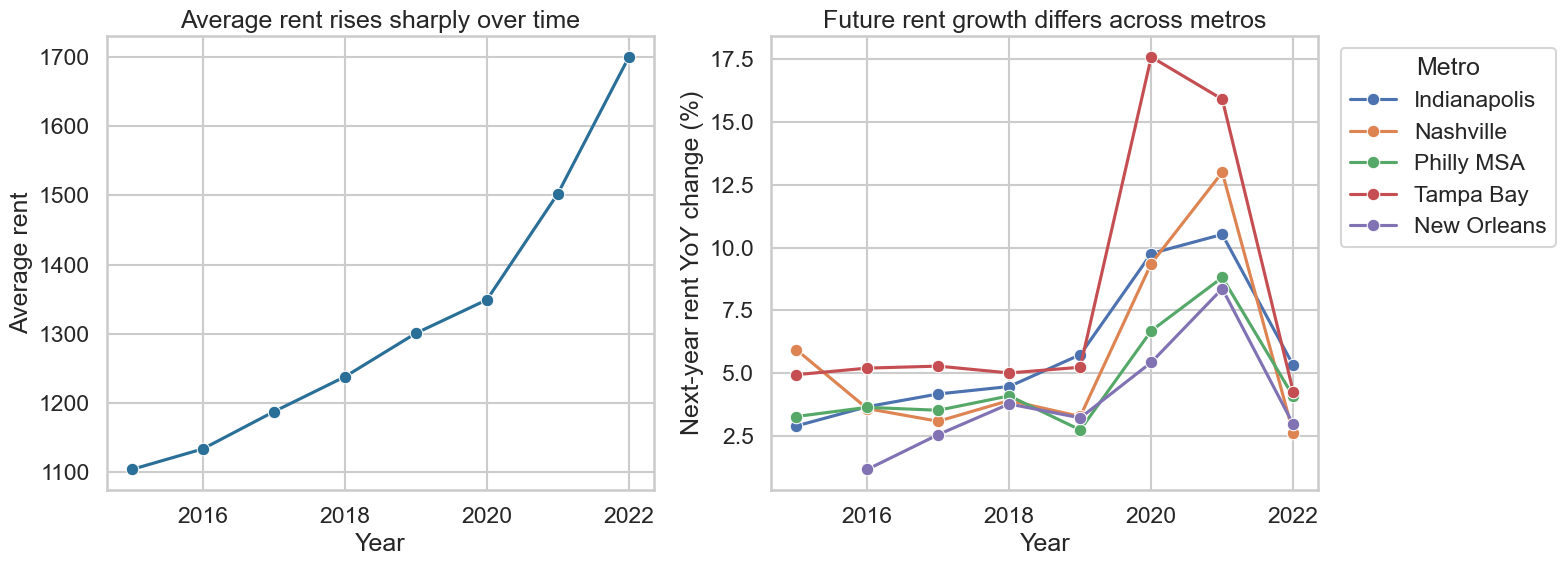

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rent_by_year = df.groupby("year")["avg_rent"].mean().reset_index()
sns.lineplot(data=rent_by_year, x="year", y="avg_rent", marker="o", ax=axes[0], color="#2a6f97")
axes[0].set_title("Average rent rises sharply over time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Average rent")

rent_growth_by_year = df.groupby(["year", "metro"])["next_year_rent_yoy_change"].mean().reset_index()
sns.lineplot(
    data=rent_growth_by_year,
    x="year",
    y="next_year_rent_yoy_change",
    hue="metro",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Future rent growth differs across metros")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Next-year rent YoY change (%)")
axes[1].legend(title="Metro", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

- Rent levels trend upward over time almost everywhere in the sample.
- Future rent growth is not constant across metros, so controlling for both metro and year in a regression is reasonable.
- The spike around 2020-2021 suggests we should be careful not to treat those years as normal baseline periods

## 3.5 Which keywords are actually moving over time?

The composite `gentrify_language_score` bundles 30 terms into a single number.
Here we are checking to see if individual keywords are actually *changing* over the study period or whether most of
them are flat. Words that trend upward likely carry more indication about neigborhood change than words that were already common in 2015 and stayed that way.


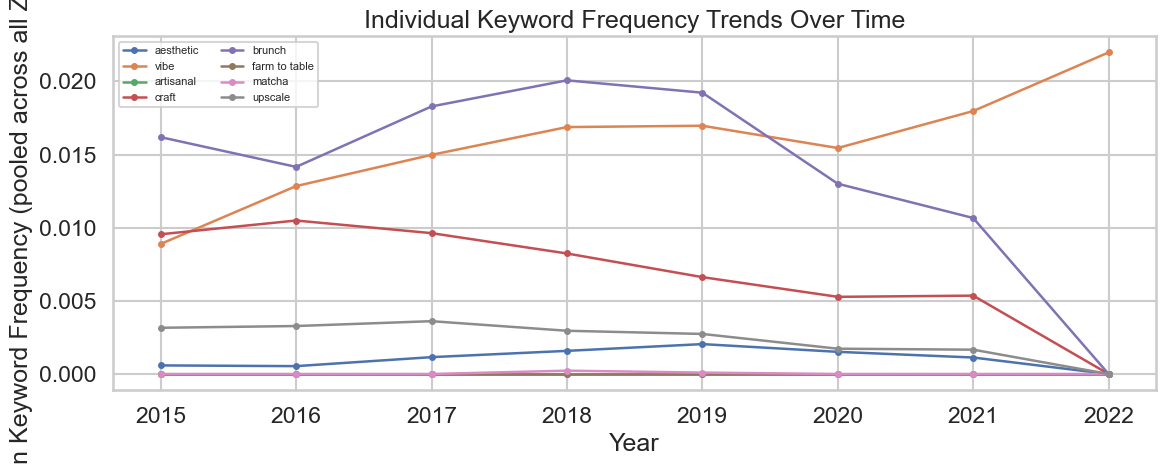

In [5]:

kw_freq_cols = [col for col in df.columns if col.startswith("kw_") and col.endswith("_freq")]

focus_kws = [c for c in kw_freq_cols if any(
    k in c for k in ["aesthetic", "vibe_", "brunch", "artisanal", "craft_", "matcha", "upscale", "farm_to_table"]
)]

kw_yearly = df.groupby("year")[focus_kws].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
for col in focus_kws:
    label = col.replace("kw_", "").replace("_freq", "").replace("_", " ")
    ax.plot(kw_yearly["year"], kw_yearly[col], marker="o", label=label, linewidth=1.8, markersize=4)

ax.set_xlabel("Year")
ax.set_ylabel("Median Keyword Frequency (pooled across all ZIP-years)")
ax.set_title("Individual Keyword Frequency Trends Over Time")
ax.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()


The composite score bundles terms with conflicting trajectories (both positive and negative). Brunch is the dominant term and rising, but it's negatively correlated with rent growth. Most other terms are flat or declining (other than 'vibe'). The composite score might be diluting the actual results

### Validating the gentrifier word list

One concern with our keyword based measure is whether the selected “gentrifier” words actually capture businesses associated with neighborhood change. To check this, we compare businesses with gentrifier-related review language to those without it.

If the word list is capturing something meaningful, we would expect businesses with these terms to look different on dimensions often associated with gentrifying commercial spaces, such as price level and ratings.

In [6]:
df["gentrify_quartile"] = pd.qcut(
    df["gentrify_language_score"],
    q=4,
    labels=["Low", "Med-Low", "Med-High", "High"]
)

df.groupby("gentrify_quartile")["avg_price_range"].mean()



/var/folders/33/4vr1mcy5543cxz5d8ysghz3m0000gp/T/ipykernel_2751/1422665851.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("gentrify_quartile")["avg_price_range"].mean()


gentrify_quartile
Low         1.480328
Med-Low     1.542014
Med-High    1.611194
High        1.631225
Name: avg_price_range, dtype: float64

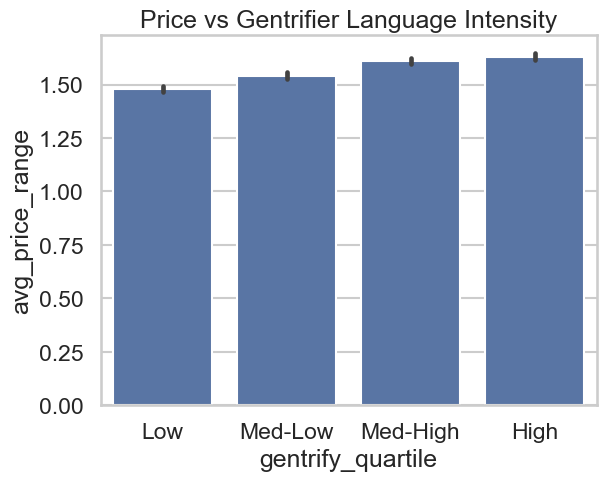

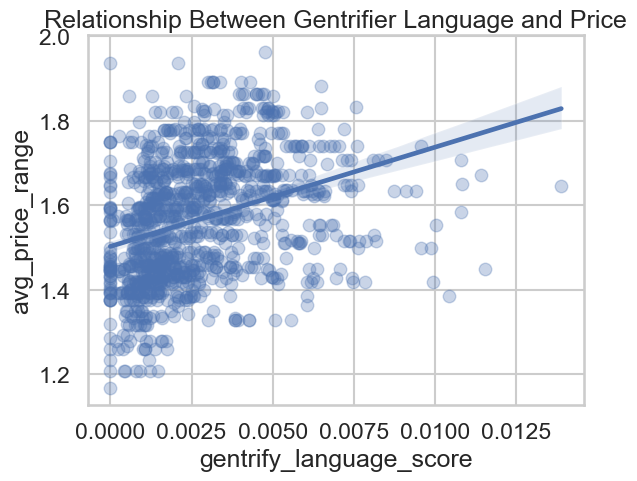

In [7]:
sns.barplot(data=df, x="gentrify_quartile", y="avg_price_range")
plt.title("Price vs Gentrifier Language Intensity")
plt.show()

sns.regplot(
    data=df,
    x="gentrify_language_score",
    y="avg_price_range",
    scatter_kws={"alpha":0.3}
)
plt.title("Relationship Between Gentrifier Language and Price")
plt.show()

We observe a positive relationship between gentrifier language intensity and price levels, suggesting that higher concentrations of these keywords are associated with more expensive businesses.

This supports the idea that the language-based measure captures meaningful variation, though the relationship appears gradual rather than sharply segmented.

## 4. Raw associations before regression

,gentrify_language_score,next_year_rent_yoy_change,total_reviews
language_quartile,,,
Q1 lowest,0.001,7.060,330.579
Q2,0.002,7.382,892.260
Q3,0.003,6.575,1908.439
Q4 highest,0.006,5.769,2527.727


,gentrify_density,next_year_rent_yoy_change,total_reviews
density_quartile,,,
Q1 lowest,0.155,6.905,422.000
Q2,0.214,7.032,901.668
Q3,0.258,6.794,1137.269
Q4 highest,0.324,6.043,3240.447


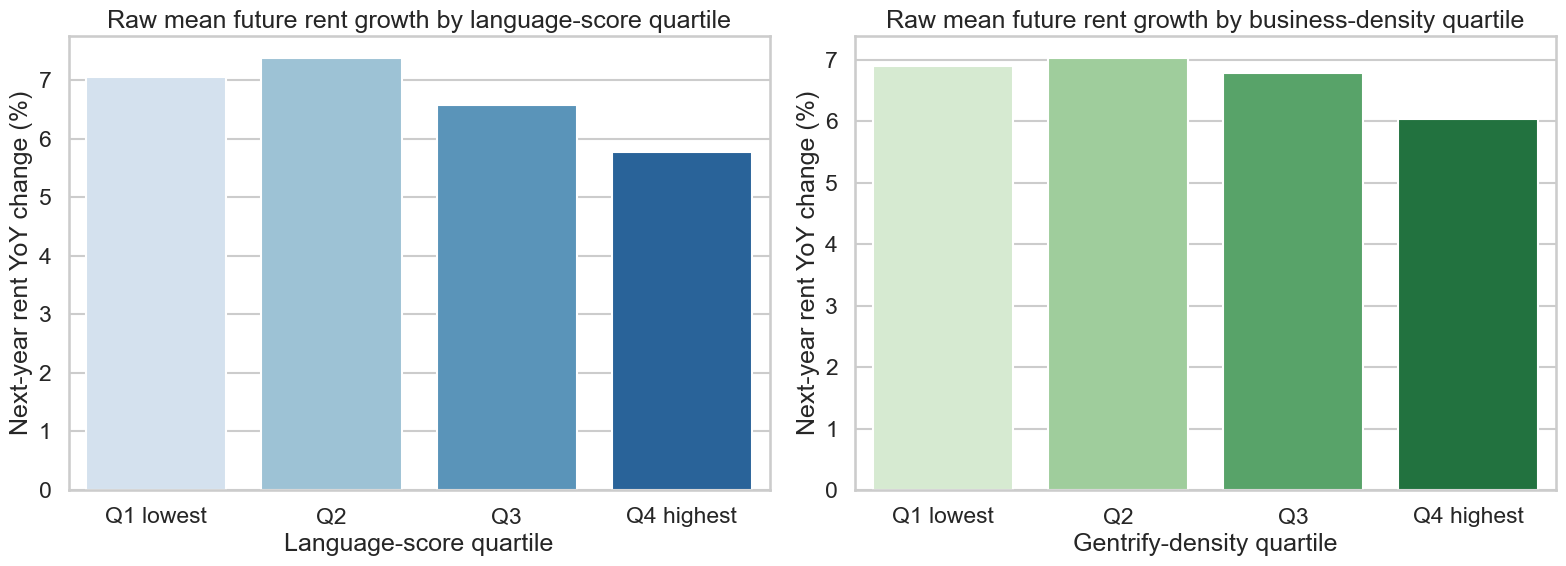

In [8]:
df["language_quartile"] = pd.qcut(
    df["gentrify_language_score"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)

df["density_quartile"] = pd.qcut(
    df["gentrify_density"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
)

language_quartiles = (
    df.groupby("language_quartile", observed=False)[
        ["gentrify_language_score", "next_year_rent_yoy_change", "total_reviews"]
    ]
    .mean()
    .round(3)
)

density_quartiles = (
    df.groupby("density_quartile", observed=False)[
        ["gentrify_density", "next_year_rent_yoy_change", "total_reviews"]
    ]
    .mean()
    .round(3)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

language_quartiles_plot = language_quartiles.reset_index()
density_quartiles_plot = density_quartiles.reset_index()

sns.barplot(
    data=language_quartiles_plot,
    x="language_quartile",
    y="next_year_rent_yoy_change",
    hue="language_quartile",
    palette="Blues",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Raw mean future rent growth by language-score quartile")
axes[0].set_xlabel("Language-score quartile")
axes[0].set_ylabel("Next-year rent YoY change (%)")

sns.barplot(
    data=density_quartiles_plot,
    x="density_quartile",
    y="next_year_rent_yoy_change",
    hue="density_quartile",
    palette="Greens",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Raw mean future rent growth by business-density quartile")
axes[1].set_xlabel("Gentrify-density quartile")
axes[1].set_ylabel("Next-year rent YoY change (%)")

plt.tight_layout()

display(language_quartiles)
display(density_quartiles)

- In the raw averages, the highest language-score quartile does not have the fastest future rent growth.
- The same basic pattern appears for `gentrify_density`.

## 5. Which review words move the most with future rent growth?

,keyword,correlation
9,charcuterie,0.089428
8,avocado toast,0.029845
7,vibes,0.011363
6,handcrafted,0.011291
5,artisan,0.007746
4,upscale,-0.070021
3,rustic,-0.071041
2,organic,-0.071801
1,hipster,-0.114898
0,brunch,-0.153983


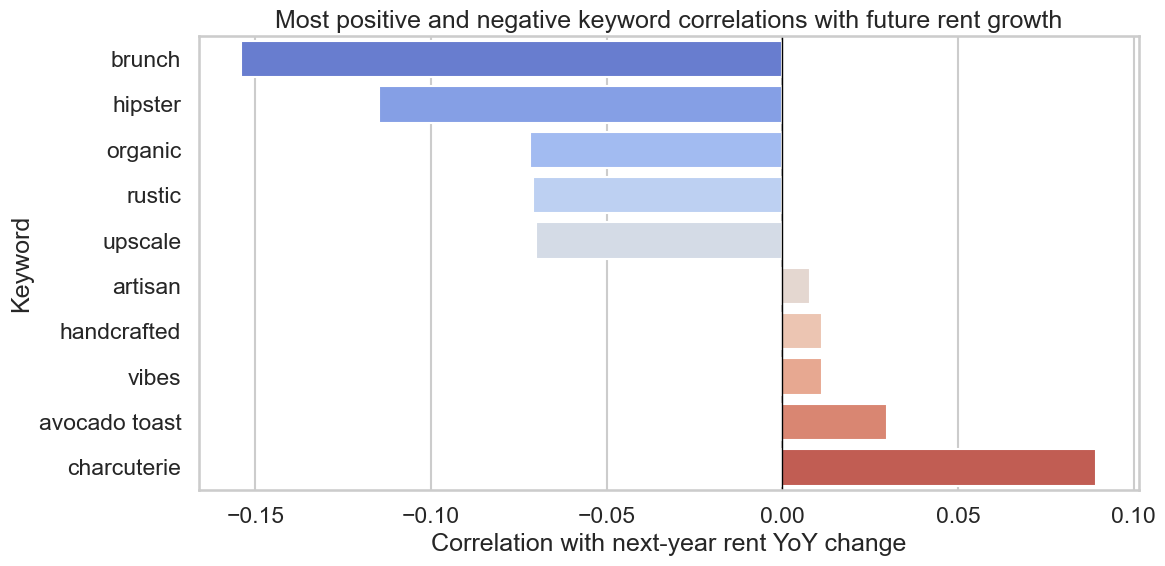

In [9]:
#just so we dont need to list all the keywords
kw_freq_cols = [col for col in df.columns if col.startswith("kw_") and col.endswith("_freq")]

keyword_corr = (
    df[kw_freq_cols + ["next_year_rent_yoy_change"]]
    .corr(numeric_only=True)["next_year_rent_yoy_change"]
    .drop("next_year_rent_yoy_change")
    .sort_values()
)

keyword_focus = pd.concat([keyword_corr.head(5), keyword_corr.tail(5)]).reset_index()
keyword_focus.columns = ["keyword", "correlation"]
keyword_focus["keyword"] = (
    keyword_focus["keyword"]
    # remove the prefix and suffix so its more readable
    .str.replace("kw_", "", regex=False)
    .str.replace("_freq", "", regex=False)
    .str.replace("_", " ", regex=False)
)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=keyword_focus,
    x="correlation",
    y="keyword",
    hue="keyword",
    palette="coolwarm",
    dodge=False,
    legend=False,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Most positive and negative keyword correlations with future rent growth")
plt.xlabel("Correlation with next-year rent YoY change")
plt.ylabel("Keyword")
plt.tight_layout()

keyword_focus.sort_values("correlation", ascending=False)

- The keyword correlations are small, which means no single term is acting like a magic predictor.
- A few terms such as `charcuterie` are mildly positive, while `brunch` and `hipster` are more negative in this sample.

## 6. Pooled regression with controls

In [10]:
predictor_corr = df[
    [
        "gentrify_language_score",
        "gentrify_density",
        "avg_price_range",
        "avg_rent",
        "log_total_reviews",
    ]
].corr().round(3)

display(predictor_corr)

model = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_language_score + gentrify_density + "
    "avg_price_range + avg_review_stars + log_total_reviews + avg_rent + C(metro) + C(year)",
    data=df,
).fit(cov_type="HC3")

model_results = (
    model.summary2()
    .tables[1]
    .loc[
        [
            "gentrify_language_score",
            "gentrify_density",
            "avg_price_range",
            "avg_review_stars",
            "log_total_reviews",
            "avg_rent",
        ],
        ["Coef.", "Std.Err.", "P>|z|"],
    ]
    .rename(columns={"Coef.": "coef", "Std.Err.": "std_err", "P>|z|": "p_value"})
    .round(4)
)

display(model_results)

language_effect_per_001 = model.params["gentrify_language_score"] * 0.001

print(f"R-squared: {model.rsquared:.3f}")
print(f"Observations used: {int(model.nobs)}")
print(
    "Interpretation: a 0.001 increase in gentrify_language_score is associated with "
    f"about {language_effect_per_001:.3f} percentage points more next-year rent growth, holding the controls constant."
)

,gentrify_language_score,gentrify_density,avg_price_range,avg_rent,log_total_reviews
gentrify_language_score,1.000,0.540,0.330,0.139,0.315
gentrify_density,0.540,1.000,0.441,0.241,0.396
avg_price_range,0.330,0.441,1.000,0.463,0.335
avg_rent,0.139,0.241,0.463,1.000,-0.157
log_total_reviews,0.315,0.396,0.335,-0.157,1.000


,coef,std_err,p_value
gentrify_language_score,141.8931,50.9843,0.0054
gentrify_density,-4.5978,1.8698,0.0139
avg_price_range,2.5491,0.8994,0.0046
avg_review_stars,0.2913,0.3505,0.4059
log_total_reviews,0.0860,0.1125,0.4449
avg_rent,-0.0038,0.0005,0.0000


R-squared: 0.667
Observations used: 1110
Interpretation: a 0.001 increase in gentrify_language_score is associated with about 0.142 percentage points more next-year rent growth, holding the controls constant.


- Once we control for metro, year, baseline rent, and review volume, `gentrify_language_score` becomes positive and statistically significant.
- `gentrify_density` turns negative in this pooled specification, while `avg_price_range` turns positive.
- The sign change between the raw quartile plots and the regression suggests confounding: these predictors are related to one another, and some are also tied to broad metro and year patterns.
- This is observational so these are associations, not causal

## 6.5 Coefficient stability across model specifications

The regression in section 6 reports estimates from the fully controlled model. But here we are checking to see how the gentrify_language_score coefficient behaves as we add controls one by one?

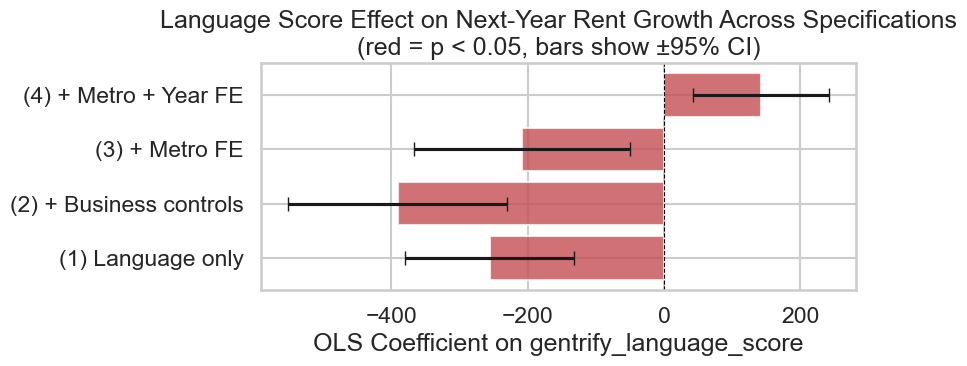

In [11]:
# Run four progressively more controlled OLS specifications
# 1) Just language score (no controls)
# 2) Language score + business controls (density, price range, review stars, review count, baseline rent)
# 3) Everything in (2) + metro fixed effects (a dummy for each city)
# 4) Everything in (3) + year fixed effects (a dummy for each year) - this is the same model as Section 6

specs_dict = {
    "(1) Language only": smf.ols(
        "next_year_rent_yoy_change ~ gentrify_language_score",
        data=df,
    ).fit(cov_type="HC3"),
    "(2) + Business controls": smf.ols(
        "next_year_rent_yoy_change ~ gentrify_language_score + gentrify_density + "
        "avg_price_range + avg_review_stars + log_total_reviews + avg_rent",
        data=df,
    ).fit(cov_type="HC3"),
    "(3) + Metro FE": smf.ols(
        "next_year_rent_yoy_change ~ gentrify_language_score + gentrify_density + "
        "avg_price_range + avg_review_stars + log_total_reviews + avg_rent + C(metro)",
        data=df,
    ).fit(cov_type="HC3"),
    "(4) + Metro + Year FE": model,  # reuse the model from section 6
}

spec_names = list(specs_dict.keys())
coefs_list = [m.params.get("gentrify_language_score", float("nan")) for m in specs_dict.values()]
ci95_list  = [m.bse.get("gentrify_language_score", float("nan")) * 1.96 for m in specs_dict.values()]
pvals_list = [m.pvalues.get("gentrify_language_score", 1.0) for m in specs_dict.values()]

bar_colors = ["#C44E52" if p < 0.05 else "gray" for p in pvals_list]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(spec_names, coefs_list, xerr=ci95_list, color=bar_colors, capsize=5, alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("OLS Coefficient on gentrify_language_score")
ax.set_title(
    "Language Score Effect on Next-Year Rent Growth Across Specifications\n"
    "(red = p < 0.05, bars show ±95% CI)"
)
plt.tight_layout()


The plot reveals how the FEs affect the signal:

- **1 -3- no year fixed effects:** the language score coefficient
 is negative and statistically significant.
- **4- adding year fixed effects:** the coefficient flips to positive
  and remains significant.

The sign flip is explained by the 2020-2021 COVID effect visible in the raw data
(section 3): during that period rent growth spiked dramatically while language scores
were actually flat or slightly declining. Without year fixed effects, that pattern
dominates the pooled estimate. After adding in FEs for times, there is a positive signal.

 This means the result in section 6 is specifically a within-year finding, in any given year, higher-language ZIPs see faster rent growth than comparable ZIPs in the same metro, after removing the common time trend.

## 7. keep only ZIP-years with at least 100 reviews

In [12]:
high_volume_df = df[df["total_reviews"] >= 100].copy()

high_volume_model = smf.ols(
    "next_year_rent_yoy_change ~ gentrify_language_score + gentrify_density + "
    "avg_price_range + avg_review_stars + log_total_reviews + avg_rent + C(metro) + C(year)",
    data=high_volume_df,
).fit(cov_type="HC3")

robustness = pd.DataFrame(
    {
        "full_sample_coef": model.params[
            ["gentrify_language_score", "gentrify_density", "avg_price_range"]
        ],
        "full_sample_p": model.pvalues[
            ["gentrify_language_score", "gentrify_density", "avg_price_range"]
        ],
        "reviews_ge_100_coef": high_volume_model.params[
            ["gentrify_language_score", "gentrify_density", "avg_price_range"]
        ],
        "reviews_ge_100_p": high_volume_model.pvalues[
            ["gentrify_language_score", "gentrify_density", "avg_price_range"]
        ],
    }
).round(4)

display(robustness)
print(f"High-volume sample size: {len(high_volume_df)}")
print(f"High-volume model R-squared: {high_volume_model.rsquared:.3f}")

,full_sample_coef,full_sample_p,reviews_ge_100_coef,reviews_ge_100_p
gentrify_language_score,141.8931,0.0054,204.3736,0.0119
gentrify_density,-4.5978,0.0139,-3.9130,0.0854
avg_price_range,2.5491,0.0046,0.7181,0.5234


High-volume sample size: 897
High-volume model R-squared: 0.690


## Final interpretation and limitations

The descriptive plots do not show a simple "more trendy Yelp language means faster future rent growth" story. But once we add basic controls the composite Yelp language score becomes positively associated with next-year rent growth. That means the data may contain some signal but the signal is clearly mixed and context-dependent.

This is still exploratory rather than causal. The business composition variables are partly static over time. Yelp users are not representative of all residents, the sample is concentrated in five metros, and the 2020-2021 housing market shock may explain part of the overall pattern. So Yelp language may be useful as an early signal of neighborhood change, but there is no clear evidence to treat it as a standalone explanation of rent increases.

- **Geographic concentration:** Our 5-metro sample (~238 ZIP codes, 2015–2022) was chosen for Yelp data quality, but results may not generalize to smaller cities, rural areas, or metros with different gentrification dynamics.
- **Static business features:** Yelp business metadata (`categories`, `price_range`) is a snapshot with no opening-date field. Our `gentrify_density` metric is constant over time for each ZIP, even if the actual business mix changed. This limits our ability to use it in a longitudinal model.
- **Reviewer demographic bias:** Yelp reviewers are not representative of the general population; they skew younger and more urban. Rising keyword frequencies may reflect the shifting composition of *who reviews on Yelp* in a neighborhood, not necessarily changes in the neighborhood itself.
- **Keyword noise:** Hand-curated terms like `craft` or `rustic` appear in non-gentrification contexts. The composite score averages across 30 terms to dilute this noise, but it remains a limitation.
- **ZORI smoothing and coverage gaps:** Zillow's smoothing algorithm may lag detection of rapid rent changes. ZIP codes with thin listing activity are excluded, which may bias our sample toward larger or more commercially active ZIPs.
- **Observational design:** All findings are associational. Without randomization or a quasi-experimental design (e.g., difference-in-differences), we cannot establish that Yelp language signals *cause* rent changes rather than simply co-occurring with them.
- **The composite score** is a crude average. Averaging 30 keyword frequencies equally weights brunch (high frequency, negative correlation with rent growth) the same as charcuterie (low frequency, positive correlation)